In [1]:
import pandas as pd 
import geopandas as gpd 
import datetime as dt
import dask.dataframe as dd

df = pd.read_csv("./data/probe-results.csv")

In [2]:
# filter to perim only 
df = df[df.collection_id == "public.eis_fire_lf_perimeter_nrt"]

# get first seen probe time for each timestep
df.probe_time = pd.to_datetime(df.probe_time)
df.newest_feature_datetime = pd.to_datetime(df.newest_feature_datetime)
df = df.sort_values(by="probe_time", ascending=True)
df = df.drop_duplicates(subset=["newest_feature_datetime"], keep='first')

# Only test AM timesteps because PM runs are mostly failing. These are from N(ight) detections
# due to known GitHub Actions issue 
# filter to only AM 
# df = df[df.newest_feature_datetime.dt.hour == 0]

df["feds_first_available_edt"] = df.probe_time - pd.Timedelta(hours=4)
df["feds_first_available_pdt"] = df.probe_time - pd.Timedelta(hours=7)


Note: Switched to orchestrator on Tuesday May 5th. As of May 26th, still using the original scheduled times. 


download FIRMS data for this time range from https://firms.modaps.eosdis.nasa.gov/active_fire/ (for last 7 days) or here https://nrt3.modaps.eosdis.nasa.gov/archive/FIRMS/noaa-20-viirs-c2/USA_contiguous_and_Hawaii/ (for last 60 days)

Use the CONUS/Hawaii file instead of global as it is smaller and has everything we need still


In [3]:

pix = dd.read_csv("./data/NOAA20/*.txt", sep=',', header=0).compute() # dask is nice for parallel reads
# pix = pd.read_csv("./data/J1_VIIRS_C2_USA_contiguous_and_Hawaii_7d.csv")
pix = gpd.GeoDataFrame(pix, geometry=gpd.points_from_xy(x=pix["longitude"], y=pix["latitude"]), crs=4326)
# filter out Hawaii (cut everything past -126 deg lon)
pix = pix.cx[-126:, :]

pix["acq_datetime"] = pd.to_datetime(pix.acq_date.astype(str) + " " + pix.acq_time.astype(str).apply(str.zfill, args=[4]))
pix["acq_datetime"] = pix.acq_datetime.dt.tz_localize("UTC")
pix["acq_datetime_pdt"] = pix.acq_datetime - pd.Timedelta(hours=7)

# note: below no longer true 
# we are only looking at the AM timestep right now because the PM timestep is broken anyways. 
# so, filter to only Night detections (~01:30) 
# pix = pix.sort_values(by="acq_time", ascending=False) 
# pix = pix[pix.daynight == "N"]


Text(0.5, 1.0, 'NOAA20 nighttime overpass times (HHMM, UTC)')

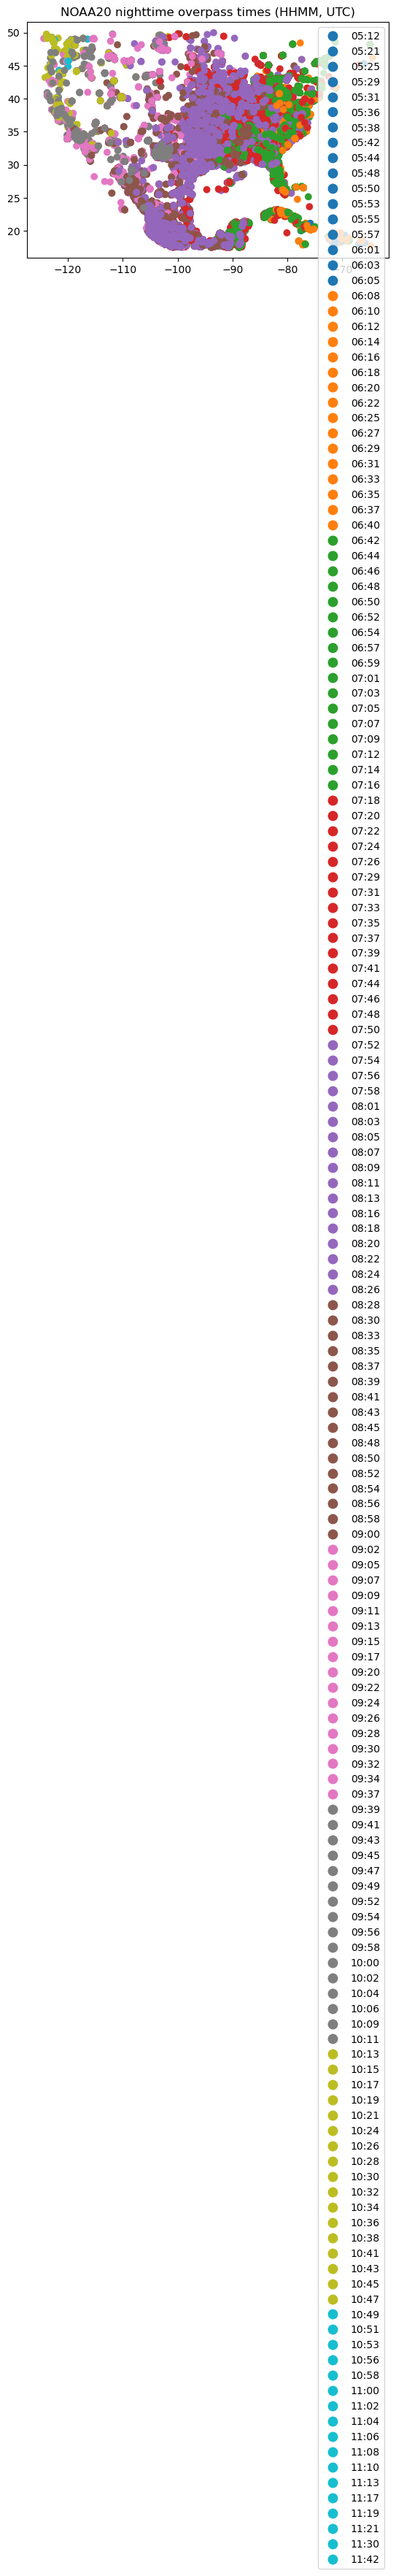

In [4]:
ax = pix[pix.daynight == "N"].plot(column="acq_time", legend=True)
ax.set_title("NOAA20 nighttime overpass times (HHMM, UTC)")

In [5]:
# filter to just the last detection in each timestep 
last = pix.sort_values(by="acq_datetime", ascending=False).drop_duplicates(subset=["acq_date", "daynight"]).copy() 

last.acq_date = pd.to_datetime(last.acq_date)

# disregard today because it is still morning 
last = last[last.acq_date.dt.date < dt.datetime.now().date()]



In [6]:
# now we need to join on timestep actually 
last["timestep"] = pd.to_datetime(last.apply(lambda r: 
                              f"{r.acq_datetime.strftime("%Y-%m-%d")} 00:00:00" if r.daynight == "N" else f"{r.acq_datetime.strftime("%Y-%m-%d")} 12:00:00", 
                              axis=1))
if last.index.name != "timestep":     
    last = last.set_index("timestep")
if df.index.name != "newest_feature_datetime":
    df = df.set_index("newest_feature_datetime")

In [7]:
joined = df.join(last, how="left")
joined["latency"] =  joined["probe_time"] - joined["acq_datetime"]
stats = joined[["probe_time", "acq_datetime", "acq_datetime_pdt", "latency", "feds_first_available_edt", "feds_first_available_pdt"]]
# drop the 28th because I manually triggered it way earlier than the schedule 
# (and the FEDS output is missing west coast data because of that)
stats = stats.drop(pd.to_datetime("2026-04-28"))

In [8]:
# there is one row with an error response from FIRMS API; drop this 
stats = stats[stats.index.notna()]
# so: the orchestrator switchover happened on May 5th. 
# In the 7 days preceeding the switchover: 
stats = stats.sort_index()

before = stats["2026-04-27":"2026-05-05"]

after = stats["2026-05-19":"2026-05-25"]

print("7 days before orchestrator swapover (running on GH Actions): ")
print(f"\tAverage AM latency: {before.latency.mean()} +/- {before.latency.std()}")
print(f"\tAverage PM latency: aprox 12 + 7:22 = 19:22 (100% of PM runs in this time period failed)")
avgl = (before.latency.sum() + ((pd.Timedelta(hours=12) + before.latency.sum()) * len(before))) / len(before)
print(f"\tOverall average latency, including failed runs (available in next run): {avgl}")

after_am = after[after.index.hour == 0]
after_pm = after[after.index.hour == 12]

print("After: most recent 7 days:")
print(f"\tAverage AM latency: {after_am.latency.mean()} +/- {after_am.latency.std()}")
print(f"\tAverage PM latency: {after_pm.latency.mean()} +/- {after_pm.latency.std()}")
avgl = after.latency.mean()
print(f"\tOverall average latency: {avgl}")




7 days before orchestrator swapover (running on GH Actions): 
	Average AM latency: 0 days 07:22:09.250000 +/- 0 days 01:58:01.758271
	Average PM latency: aprox 12 + 7:22 = 19:22 (100% of PM runs in this time period failed)
	Overall average latency, including failed runs (available in next run): 3 days 06:19:23.250000
After: most recent 7 days:
	Average AM latency: 0 days 05:36:01.571428 +/- 0 days 00:46:05.147425
	Average PM latency: 0 days 02:41:19 +/- 0 days 00:31:47.187283
	Overall average latency: 0 days 04:08:40.285714


In [9]:
stats

,probe_time,acq_datetime,acq_datetime_pdt,latency,feds_first_available_edt,feds_first_available_pdt
newest_feature_datetime,,,,,,
2026-04-08 00:00:00,2026-04-09 12:09:31+00:00,2026-04-08 11:02:00+00:00,2026-04-08 04:02:00+00:00,1 days 01:07:31,2026-04-09 08:09:31+00:00,2026-04-09 05:09:31+00:00
2026-04-09 00:00:00,2026-04-09 17:47:52+00:00,2026-04-09 10:43:00+00:00,2026-04-09 03:43:00+00:00,0 days 07:04:52,2026-04-09 13:47:52+00:00,2026-04-09 10:47:52+00:00
2026-04-10 00:00:00,2026-04-10 17:07:26+00:00,2026-04-10 10:24:00+00:00,2026-04-10 03:24:00+00:00,0 days 06:43:26,2026-04-10 13:07:26+00:00,2026-04-10 10:07:26+00:00
2026-04-10 12:00:00,2026-04-11 02:50:03+00:00,2026-04-10 21:48:00+00:00,2026-04-10 14:48:00+00:00,0 days 05:02:03,2026-04-10 22:50:03+00:00,2026-04-10 19:50:03+00:00
2026-04-11 12:00:00,2026-04-12 03:30:00+00:00,2026-04-11 21:27:00+00:00,2026-04-11 14:27:00+00:00,0 days 06:03:00,2026-04-11 23:30:00+00:00,2026-04-11 20:30:00+00:00
2026-04-12 00:00:00,2026-04-12 16:49:52+00:00,2026-04-12 09:47:00+00:00,2026-04-12 02:47:00+00:00,0 days 07:02:52,2026-04-12 12:49:52+00:00,2026-04-12 09:49:52+00:00
2026-04-12 12:00:00,2026-04-13 01:11:52+00:00,2026-04-12 21:10:00+00:00,2026-04-12 14:10:00+00:00,0 days 04:01:52,2026-04-12 21:11:52+00:00,2026-04-12 18:11:52+00:00
2026-04-13 00:00:00,2026-04-13 17:47:06+00:00,2026-04-13 09:32:00+00:00,2026-04-13 02:32:00+00:00,0 days 08:15:06,2026-04-13 13:47:06+00:00,2026-04-13 10:47:06+00:00
2026-04-14 00:00:00,2026-04-14 17:38:00+00:00,2026-04-14 10:49:00+00:00,2026-04-14 03:49:00+00:00,0 days 06:49:00,2026-04-14 13:38:00+00:00,2026-04-14 10:38:00+00:00
